# [LAB] Surrogate Models for XAI — LIME & SHAP

## Overview

In this lab you will apply **surrogate model** techniques to explain how ML models make decisions.

| Technique | What it does | When to use |
|-----------|-------------|-------------|
| **LIME (text)** | Highlights which words drove a prediction | Text classification |
| **LIME (image)** | Highlights which image regions matter | Image classification |
| **SHAP** | Fair attribution via Shapley values | Regression / any model |

### What you will build

1. A **Naive Bayes** text classifier on 20 Newsgroups — then explain individual predictions with LIME
2. An **MLP** image classifier on Olivetti faces — then visualize superpixel contributions
3. An **XGBoost** regression model on Boston Housing — then analyze feature impacts globally

> Stuck? Refer to the **solution notebook** `[0430]4.Surrogate_solution.ipynb`.

## Section 0 — Setup

Run the cell below once. It installs `lime`, `scikit-image`, `shap`, and `xgboost` if they are not already installed.

In [ ]:
import importlib.util, subprocess, sys
from time import perf_counter

def ensure_package(package_name, import_name=None):
    """Install package if not already available."""
    module_name = import_name or package_name
    if importlib.util.find_spec(module_name) is None:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name, "-q"])

ensure_package("lime")
ensure_package("scikit-image", "skimage")
ensure_package("shap")
ensure_package("xgboost")

print("All dependencies are ready.")

## Section 1 — Introduction to Surrogate Models & LIME

**Surrogate models** approximate complex "black-box" ML models with a simpler, interpretable model — *locally*, near one prediction at a time.

**LIME** (Local Interpretable Model-agnostic Explanations) works in three steps:

```
1. Pick one prediction to explain
2. Perturb the input (turn words/pixels on & off) and get the black-box's responses
3. Fit a simple linear model on those perturbations — the weights are your explanation
```

LIME is **model-agnostic**: it works with any classifier as long as you can call `predict_proba(input)`.

> Key limitation: LIME assumes local linearity and may differ across runs (stochastic sampling). Always check stability by running explain_instance multiple times.

**In this lab you will use LIME to explain:**
- A text classifier (Naive Bayes on 20 Newsgroups)
- An image classifier (MLP on Olivetti faces)
- A regression model (XGBoost on Boston Housing) — via **SHAP** (a more theoretically grounded alternative)

## Section 2 — Text Classification with Naive Bayes

**Concept:** The 20 Newsgroups dataset contains ~20,000 newsgroup posts across 20 topics — perfect for multi-class text classification. We use **Multinomial Naive Bayes** with **TF-IDF** features as our black-box model. Despite being interpretable on its own, treating it as a black box lets us practice LIME in a well-understood setting.

| Step | What we do |
|------|-----------|
| TF-IDF | Convert raw text into numeric feature vectors (word frequencies) |
| Naive Bayes | Train a probabilistic classifier assuming word independence |
| Pipeline | Chain TF-IDF + NB so one call handles preprocessing + prediction |

**What to observe:** Check the F1-score and note which classes are harder to distinguish.  
**Try it yourself:** After training, predict on `newsgroups_test.data[0]` and print the top 3 predicted categories.

In [ ]:
# Example 5.1  Load the 20 Newsgroups dataset

from sklearn.datasets import fetch_20newsgroups

newsgroups_train = fetch_20newsgroups(subset='train')
newsgroups_test  = fetch_20newsgroups(subset='test')

# Shorten class names for readability
class_names = [
    x.split('.')[-1] if 'misc' not in x else '.'.join(x.split('.')[-2:])
    for x in newsgroups_train.target_names
]

class_names[3] = 'pc.hardware'
class_names[4] = 'mac.hardware'

print(f"Number of classes  : {len(class_names)}")
print(f"Training documents : {len(newsgroups_train.data)}")
print(f"Test documents     : {len(newsgroups_test.data)}")
print("Classes:", class_names)

In [ ]:
# Example 5.2  Train a Multinomial Naive Bayes classifier using TF-IDF features

import sklearn
import sklearn.metrics
from sklearn.naive_bayes import MultinomialNB

# TF-IDF: converts raw text into numeric vectors weighted by term frequency × inverse doc frequency
vectorizer = sklearn.feature_extraction.text.TfidfVectorizer(lowercase=False)
train_vectors = vectorizer.fit_transform(newsgroups_train.data)
test_vectors  = vectorizer.transform(newsgroups_test.data)

# Train the Naive Bayes model
nb = MultinomialNB(alpha=.01)
nb.fit(train_vectors, newsgroups_train.target)

# Evaluate with weighted F1-score
pred = nb.predict(test_vectors)
f1 = sklearn.metrics.f1_score(newsgroups_test.target, pred, average='weighted')
print(f"Weighted F1-score: {f1:.4f}")

0.8350184193998174

In [ ]:
# Example 5.3  Build a Pipeline: TF-IDF → Naive Bayes
# A pipeline chains preprocessing and model so a single call handles both steps.

from sklearn.pipeline import make_pipeline

pipe = make_pipeline(vectorizer, nb)

# Predict class probabilities for test document 0
predict_classes = pipe.predict_proba([newsgroups_test.data[0]]).round(3)[0]
print(f"Probability vector shape: {predict_classes.shape}")
print(f"Sum of probabilities: {predict_classes.sum():.3f}  (should be 1.0)")

[0.001 0.01  0.003 0.047 0.006 0.002 0.003 0.521 0.022 0.008 0.025 0.
 0.331 0.003 0.006 0.    0.003 0.    0.001 0.009]


In [ ]:
# Example 5.4  Display class probabilities in ranked order (most likely first)

rank = sorted(range(len(predict_classes)), key=lambda i: predict_classes[i], reverse=True)
print("Top predicted classes for test document 0:")
for rank_index in rank[:5]:  # show top 5 only
    print('[{:>2}]  class {:>2}  ({})  {:.1%}'.format(
        rank.index(rank_index) + 1,
        rank_index,
        class_names[rank_index],
        predict_classes[rank_index]))

[    1] 	7  	class (52.1%)
[    2] 	12 	class (33.1%)
[    3] 	3  	class (4.7%)
[    4] 	10 	class (2.5%)
[    5] 	8  	class (2.2%)
[    6] 	1  	class (1.0%)
[    7] 	19 	class (0.9%)
[    8] 	9  	class (0.8%)
[    9] 	4  	class (0.6%)
[   10] 	14 	class (0.6%)
[   11] 	2  	class (0.3%)
[   12] 	6  	class (0.3%)
[   13] 	13 	class (0.3%)
[   14] 	16 	class (0.3%)
[   15] 	5  	class (0.2%)
[   16] 	0  	class (0.1%)
[   17] 	18 	class (0.1%)
[   18] 	11 	class (0.0%)
[   19] 	15 	class (0.0%)
[   20] 	17 	class (0.0%)


## Section 3 — LIME for Text Explanation

**Concept:** LIME for text perturbs a document by randomly removing words, collects the black-box model's responses to each perturbed version, and fits a sparse linear model. The resulting **coefficients** show which words most influenced the prediction — positive weights push toward the predicted class, negative weights push away.

**What to observe:**
- Do the highlighted words make intuitive sense for the predicted newsgroup?
- Compare the explanation for a *high-confidence* vs. *low-confidence* prediction.

**Try it yourself:** Change `top_labels=1` to `top_labels=3` in `explain_instance` and call `exp.show_in_notebook()` to see explanations for multiple classes at once.

In [ ]:
# Example 5.5  Declare a LIME text explainer
# (lime is installed automatically in the Setup cell at the top)

from lime.lime_text import LimeTextExplainer

# TODO: Instantiate LimeTextExplainer with our class_names list
# Hint: LimeTextExplainer(class_names=...)
explainer = LimeTextExplainer(class_names=class_names)

In [ ]:
# Example 5.6  Generate LIME explanation for test document 0
# explain_instance samples perturbed texts and fits a local linear model

exp = explainer.explain_instance(
    newsgroups_test.data[0],   # the document to explain
    pipe.predict_proba,         # classifier function
    top_labels=1               # explain only the top predicted class
)

split() requires a non-empty pattern match.


In [ ]:
# Example 5.7  Check which class labels are available in the explanation
print("Available labels in explanation:", exp.available_labels())
print("Corresponds to class:", [class_names[i] for i in exp.available_labels()])

[7]

In [ ]:
# Example 5.8  Visualize the LIME explanation inline in the notebook
# Highlighted words in green increase confidence; red words decrease it.

exp.show_in_notebook(text=newsgroups_test.data[0])

In [ ]:
# Example 5.9  Explain test document 5 — observe how the explanation differs
from lime.lime_text import LimeTextExplainer

idx = 5

explainer = LimeTextExplainer(class_names=class_names)
exp = explainer.explain_instance(newsgroups_test.data[idx], pipe.predict_proba, top_labels=1)
predict_classes = pipe.predict_proba([newsgroups_test.data[idx]]).round(3)[0]
rank = sorted(range(len(predict_classes)), key=lambda i: predict_classes[i], reverse=True)

print(f"Document id   : {idx}")
print(f"Predicted class: {class_names[nb.predict(test_vectors[idx]).reshape(1,-1)[0,0]]}")
print(f"True class     : {class_names[newsgroups_test.target[idx]]}")
print(f"\nTop predicted class: {class_names[rank[0]]}")
print("Top 5 influential words:")
for word, weight in exp.as_list(rank[0])[:5]:
    direction = "↑ supports" if weight > 0 else "↓ opposes"
    print(f"  {word:20s}  {direction}  ({weight:+.4f})")

exp.show_in_notebook(text=newsgroups_test.data[idx])

split() requires a non-empty pattern match.


Document id: 5
Predicted class: med
True class: med
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
[13, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19]
Explanation for class med
('fungus', 0.001639867543079976)
('infection', 0.001604138623743136)
('yeast', 0.0015525958446041238)
('Candida', 0.0014802492187345109)
('candida', 0.0014374954360360217)
('ocom', 0.0014308177163502465)
('infections', 0.0012992497818976093)
('mucosal', 0.001231287901317231)
('Yeast', 0.0012205686521592895)
('deficiency', 0.001130419477412044)


**Q1:** Look at the LIME explanation for test document 0.
- Which words most strongly support the predicted class?
- Do you think those words are genuinely meaningful, or could they be spurious correlations?

**Answer:** *(Write your answer here)*

(-0.5, 1279.5, 1279.5, -0.5)

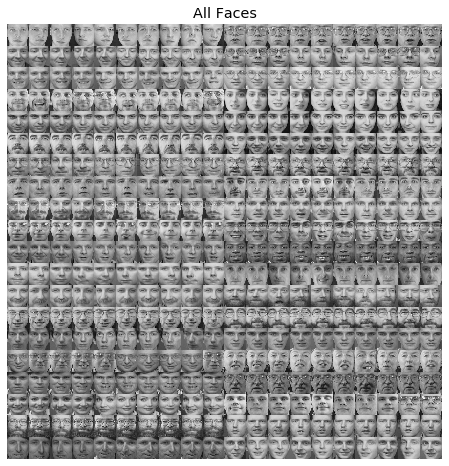

In [ ]:
# Example 5.10  Load the Olivetti Faces dataset and convert to RGB (LIME requires color images)

import numpy as np
import matplotlib.pyplot as plt
from skimage.color import gray2rgb, rgb2gray
from skimage.util import montage
from sklearn.datasets import fetch_olivetti_faces

faces = fetch_olivetti_faces()

# Convert grayscale 64×64 images to RGB (required by LimeImageExplainer)
X_vec = np.stack([gray2rgb(img) for img in faces.data.reshape((-1, 64, 64))], 0)
y_vec = faces.target.astype(np.uint8)

print(f"Dataset: {X_vec.shape[0]} images, {len(np.unique(y_vec))} individuals")
print(f"Image shape: {X_vec.shape[1:]}  (H × W × C)")

%matplotlib inline
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(montage(X_vec[:, :, :, 0]), cmap='gray', interpolation='none')
ax.set_title('All 400 Olivetti Faces (40 individuals × 10 images)')
ax.axis('off')
plt.tight_layout()

(-0.5, 63.5, 63.5, -0.5)

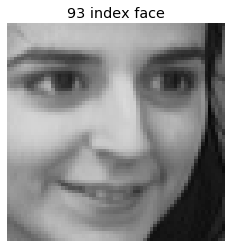

In [ ]:
# Example 5.11  Display a single face image to inspect the data

index = 93
plt.figure(figsize=(4, 4))
plt.imshow(X_vec[index], cmap='gray')
plt.title(f'Face index {index}  (individual {y_vec[index]})')
plt.axis('off')
plt.show()

## Section 4 — LIME for Image Explanation

**Concept:** For images, LIME segments the image into **superpixels** (coherent regions using SLIC/quickshift), then randomly turns superpixels on/off to create perturbed versions. After collecting the classifier's predictions on each perturbation, it fits a linear model — the superpixel weights reveal which *regions* drove the classification decision.

```
Original image
  → Segment into superpixels
  → Create 1,000 perturbed versions (some regions hidden)
  → Run classifier on each
  → Fit linear model on perturbation–prediction pairs
  → Top positive superpixels = what the model "sees"
```

**What to observe:** Green regions = positive evidence for the predicted class. Do they correspond to expected facial features (eyes, nose, jaw)?

**Try it yourself:** Change the segmenter to `'quickshift'` or `'felzenszwalb'` and compare the resulting superpixel shapes and explanation stability.

In [ ]:
# Example 5.12  Adapting a classifier for LIME
#
# LIME's classifier_fn must accept a list of images and return a 2-D array of class
# probabilities with shape (n_images, n_classes).
#
# For scikit-learn pipelines this is simply:   pipeline.predict_proba(images)
# For deep learning models (TF/PyTorch) you would wrap the forward pass, e.g.:
#   def predict_proba(images):
#       return model(torch.tensor(images)).softmax(-1).numpy()
#
# In this notebook we use 'simple_pipeline.predict_proba' directly — no wrapper needed.
print("Using simple_pipeline.predict_proba as the LIME classifier function.")

In [ ]:
# Example 5.13  Split the Olivetti dataset into training (70%) and test (30%)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y_vec, train_size=0.70, random_state=42
)

print(f"Training set : {X_train.shape[0]} images")
print(f"Test set     : {X_test.shape[0]} images")

In [ ]:
# Example 5.14  Build a preprocessing pipeline for the MLP classifier
# Steps: convert RGB → grayscale → flatten → MLP (no normalisation yet)

from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier

class PipeStep(object):
    """Wrapper for turning a function into a sklearn pipeline step (no fitting needed)."""
    def __init__(self, step_func):
        self._step_func = step_func
    def fit(self, *args):
        return self
    def transform(self, X):
        return self._step_func(X)

makegray_step = PipeStep(lambda img_list: [rgb2gray(img) for img in img_list])
flatten_step  = PipeStep(lambda img_list: [img.ravel() for img in img_list])

simple_pipeline = Pipeline([
    ('Make Gray',    makegray_step),
    ('Flatten Image', flatten_step),
    ('MLP', MLPClassifier(
        activation='relu',
        hidden_layer_sizes=(400, 40),
        random_state=1)),
])

In [ ]:
# Example 5.15  Fit the MLP pipeline on training data (may take ~30 seconds)

simple_pipeline.fit(X_train, y_train)
print("Training complete.")

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.


Pipeline(memory=None,
         steps=[('Make Gray', <__main__.PipeStep object at 0x7f4ebe359ac8>),
                ('Flatten Image', <__main__.PipeStep object at 0x7f4ebe359668>),
                ('MLP',
                 MLPClassifier(activation='relu', alpha=0.0001,
                               batch_size='auto', beta_1=0.9, beta_2=0.999,
                               early_stopping=False, epsilon=1e-08,
                               hidden_layer_sizes=(400, 40),
                               learning_rate='constant',
                               learning_rate_init=0.001, max_fun=15000,
                               max_iter=200, momentum=0.9, n_iter_no_change=10,
                               nesterovs_momentum=True, power_t=0.5,
                               random_state=1, shuffle=True, solver='adam',
                               tol=0.0001, validation_fraction=0.1,
                               verbose=False, warm_start=False))],
         verbose=False)

In [ ]:
# Example 5.16  Evaluate the pipeline with a classification report

from sklearn.metrics import classification_report

def test_model(X_test, y_test):
    pipe_pred_test = simple_pipeline.predict(X_test)
    print(classification_report(y_true=y_test, y_pred=pipe_pred_test))

print("=== Pipeline performance (no normalisation) ===")
test_model(X_test, y_test)

              precision    recall  f1-score   support

           0       0.33      0.33      0.33         3
           1       1.00      1.00      1.00         3
           2       1.00      0.75      0.86         4
           3       1.00      0.80      0.89         5
           4       1.00      1.00      1.00         3
           5       0.33      1.00      0.50         1
           6       0.50      1.00      0.67         1
           7       0.67      0.67      0.67         3
           8       1.00      1.00      1.00         2
           9       1.00      0.40      0.57         5
          10       1.00      1.00      1.00         3
          11       0.43      1.00      0.60         3
          12       0.50      1.00      0.67         1
          13       0.80      1.00      0.89         4
          14       0.50      0.50      0.50         2
          15       0.67      1.00      0.80         2
          17       1.00      1.00      1.00         2
          18       0.80    

In [ ]:
# Example 5.17  Improved pipeline: add a Normalizer preprocessing step
# Normalizer scales each sample to unit norm — useful for MLP on image data.

from sklearn.preprocessing import Normalizer

simple_pipeline = Pipeline([
    ('Make Gray',     makegray_step),
    ('Flatten Image', flatten_step),
    ('Normalize',     Normalizer()),
    ('MLP', MLPClassifier(
        activation='relu',
        hidden_layer_sizes=(400, 40),
        random_state=1)),
])

simple_pipeline.fit(X_train, y_train)

print("=== Pipeline performance (with Normalizer) ===")
test_model(X_test, y_test)

              precision    recall  f1-score   support

           0       0.50      0.33      0.40         3
           1       1.00      1.00      1.00         3
           2       1.00      0.75      0.86         4
           3       1.00      0.20      0.33         5
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         1
           6       0.00      0.00      0.00         1
           7       0.50      0.67      0.57         3
           8       1.00      1.00      1.00         2
           9       0.75      0.60      0.67         5
          10       1.00      1.00      1.00         3
          11       0.67      0.67      0.67         3
          12       0.14      1.00      0.25         1
          13       0.80      1.00      0.89         4
          14       0.67      1.00      0.80         2
          15       1.00      1.00      1.00         2
          16       0.00      0.00      0.00         0
          17       0.67    

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.


In [ ]:
# Example 5.18  Best-performing pipeline configuration
# Larger hidden layers + smaller alpha (L2 regularisation) + smaller epsilon improve accuracy.

simple_pipeline = Pipeline([
    ('Make Gray',     makegray_step),
    ('Flatten Image', flatten_step),
    ('Normalize',     Normalizer()),
    ('MLP', MLPClassifier(
        activation='relu',
        alpha=1e-7,
        epsilon=1e-6,
        hidden_layer_sizes=(800, 120),
        random_state=1)),
])

simple_pipeline.fit(X_train, y_train)

print("=== Best pipeline performance ===")
test_model(X_test, y_test)

              precision    recall  f1-score   support

           0       0.50      0.33      0.40         3
           1       1.00      1.00      1.00         3
           2       1.00      0.25      0.40         4
           3       1.00      0.60      0.75         5
           4       1.00      1.00      1.00         3
           5       0.33      1.00      0.50         1
           6       0.00      0.00      0.00         1
           7       0.75      1.00      0.86         3
           8       1.00      1.00      1.00         2
           9       0.80      0.80      0.80         5
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       0.33      1.00      0.50         1
          13       0.80      1.00      0.89         4
          14       0.67      1.00      0.80         2
          15       0.67      1.00      0.80         2
          16       0.00      0.00      0.00         0
          17       1.00    

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.


In [ ]:
# Example 5.19  Declare the LIME Image Explainer and the SLIC segmentation algorithm
# Segmentation splits the image into superpixels — LIME then turns them on/off.

from lime import lime_image
from lime.wrappers.scikit_image import SegmentationAlgorithm

explainer = lime_image.LimeImageExplainer()

# Available segmentation algorithms: 'quickshift' (default), 'slic', 'felzenszwalb'
segmenter = SegmentationAlgorithm(
    'slic',
    n_segments=100,    # number of superpixels
    compactness=1,     # higher = more square-shaped segments
    sigma=1)           # Gaussian smoothing before segmentation

print("LIME Image Explainer ready. Segmentation algorithm: SLIC")

In [ ]:
# Example 5.20  Build the surrogate explanation model for Olivetti test image 0
# (%%time is not available in all kernels; we use perf_counter instead)

from time import perf_counter

olivetti_test_index = 0

start_time = perf_counter()
exp = explainer.explain_instance(
    X_test[olivetti_test_index],
    classifier_fn = simple_pipeline.predict_proba,
    top_labels=6,
    num_samples=1000,
    segmentation_fn=segmenter)
elapsed_time = perf_counter() - start_time
print(f"Elapsed: {elapsed_time:.2f}s")

CPU times: user 2.85 s, sys: 916 ms, total: 3.77 s
Wall time: 2.11 s


Text(0.5, 1.0, 'Show mask only')

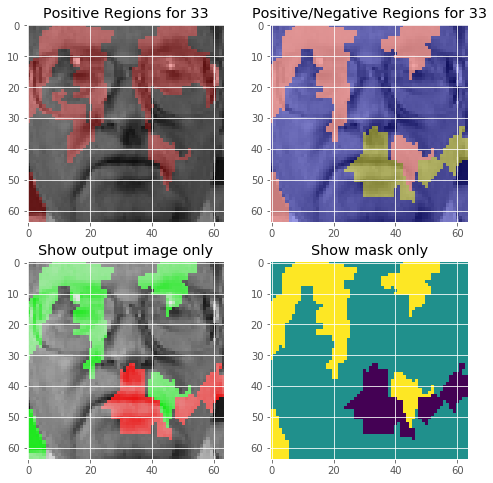

In [ ]:
# Example 5.21  Visualize the LIME explanation for Olivetti test image 0

from skimage.color import label2rgb

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(8, 8))

# ── Positive regions (what supports the prediction) ──
temp, mask = exp.get_image_and_mask(
    y_test[olivetti_test_index],
    positive_only=True, num_features=8, hide_rest=False)
ax1.imshow(label2rgb(mask, temp, bg_label=0), interpolation='nearest')
ax1.set_title(f'Positive regions → class {y_test[olivetti_test_index]}')
ax1.axis('off')

# ── Both positive and negative regions ──
temp, mask = exp.get_image_and_mask(
    y_test[olivetti_test_index],
    positive_only=False, num_features=8, hide_rest=False)
ax2.imshow(label2rgb(4 - mask, temp, bg_label=0), interpolation='nearest')
ax2.set_title('Positive / Negative regions')
ax2.axis('off')

# ── Original image ──
ax3.imshow(temp, interpolation='nearest')
ax3.set_title('Original image')
ax3.axis('off')

# ── Mask only ──
ax4.imshow(mask, interpolation='nearest')
ax4.set_title('Superpixel mask')
ax4.axis('off')

plt.tight_layout()

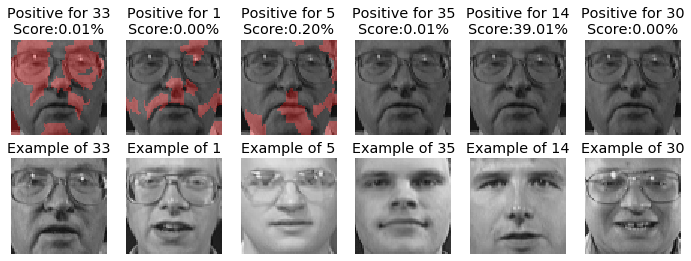

In [ ]:
# Example 5.22  Visualize explanations for top-6 predicted classes side by side
# Each column: left = LIME explanation, right = a ground truth example of that class

def show_extra_info(test, test_index):
    pipe_pred_prop = simple_pipeline.predict_proba(test)
    fig, m_axs = plt.subplots(2, 6, figsize=(12, 4))
    for i, (c_ax, gt_ax) in zip(exp.top_labels, m_axs.T):
        temp, mask = exp.get_image_and_mask(
            i, positive_only=True, num_features=12,
            hide_rest=False, min_weight=0.001)
        c_ax.imshow(label2rgb(mask, temp, bg_label=0), interpolation='nearest')
        c_ax.set_title(f'Class {i}\n{100*pipe_pred_prop[test_index, i]:.1f}%')
        c_ax.axis('off')

        face_id = np.random.choice(np.where(y_train == i)[0])
        gt_ax.imshow(X_train[face_id])
        gt_ax.set_title(f'Example {i}')
        gt_ax.axis('off')

    plt.suptitle(f'Test image {test_index}: LIME explanation (top) vs. reference faces (bottom)',
                 fontsize=10)
    plt.tight_layout()

show_extra_info(X_test, 1)

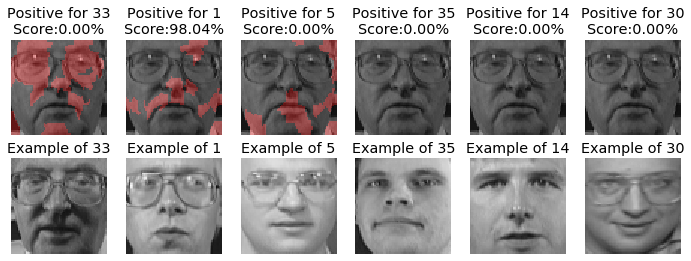

In [ ]:
# TODO: Try a different test image index (e.g., 25) and observe the explanation
show_extra_info(X_test, 25)

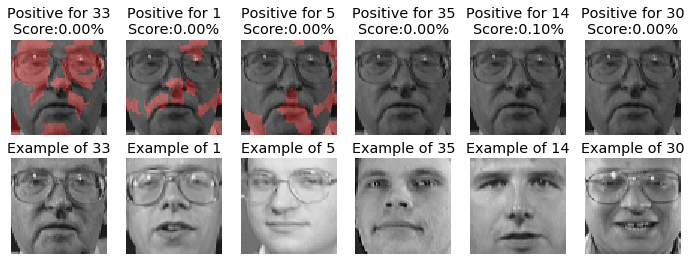

In [ ]:
# TODO: Try another test image index (e.g., 101) — does the explanation look reasonable?
show_extra_info(X_test, 101)

**Q2:** Look at the face explanation images (positive/negative regions).
- Which facial regions seem most important for identifying different individuals?
- Why might the model rely on background regions? Is that a problem?

**Answer:** *(Write your answer here)*

## Section 5 — SHAP: SHapley Additive exPlanations

**Concept:** SHAP is grounded in **cooperative game theory**. It assigns each feature a *Shapley value* — the feature's average marginal contribution across all possible orderings of features.

$$\phi_i = \sum_{S \subseteq F \setminus \{i\}} \frac{|S|!(|F|-|S|-1)!}{|F|!} \left[ f(S \cup \{i\}) - f(S) \right]$$

Unlike LIME, SHAP guarantees three key properties:

| Property | Meaning |
|----------|---------|
| **Local accuracy** | SHAP values sum exactly to the model output |
| **Missingness** | Features absent in input get SHAP = 0 |
| **Consistency** | If a feature matters more in a new model, its SHAP value won't decrease |

**TreeSHAP** computes exact Shapley values for tree-based models (XGBoost, LightGBM) in polynomial time — no sampling needed.

**Dataset: Boston Housing** — 506 data points, 13 features predicting median home value (MEDV) in $1,000s.

In [ ]:
# Example 5.23  Load the Boston Housing dataset and split into train/test sets
# shap.datasets.boston() was removed in shap >= 0.42; we use fetch_openml as fallback.

import shap
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

if hasattr(shap.datasets, "boston"):
    X, y = shap.datasets.boston()
else:
    boston = fetch_openml(name="boston", version=1, as_frame=True)
    X = boston.data
    y = boston.target.astype(float)

# XGBoost requires numeric dtypes; convert any 'category' columns to int
if hasattr(X, "select_dtypes"):
    category_columns = X.select_dtypes(include=["category"]).columns
    if len(category_columns) > 0:
        X = X.copy()
        for column in category_columns:
            X[column] = X[column].cat.codes.astype("int64")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

X_train[:10]

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
42,0.14150,0.0,6.91,0.0,0.448,6.169,6.6,5.7209,3.0,233.0,17.9,383.37,5.81
58,0.15445,25.0,5.13,0.0,0.453,6.145,29.2,7.8148,8.0,284.0,19.7,390.68,6.86
385,16.81180,0.0,18.10,0.0,0.700,5.277,98.1,1.4261,24.0,666.0,20.2,396.90,30.81
78,0.05646,0.0,12.83,0.0,0.437,6.232,53.7,5.0141,5.0,398.0,18.7,386.40,12.34
424,8.79212,0.0,18.10,0.0,0.584,5.565,70.6,2.0635,24.0,666.0,20.2,3.65,17.16
160,1.27346,0.0,19.58,1.0,0.605,6.250,92.6,1.7984,5.0,403.0,14.7,338.92,5.50
185,0.06047,0.0,2.46,0.0,0.488,6.153,68.8,3.2797,3.0,193.0,17.8,387.11,13.15
101,0.11432,0.0,8.56,0.0,0.520,6.781,71.3,2.8561,5.0,384.0,20.9,395.58,7.67
268,0.54050,20.0,3.97,0.0,0.575,7.470,52.6,2.8720,5.0,264.0,13.0,390.30,3.16
173,0.09178,0.0,4.05,0.0,0.510,6.416,84.1,2.6463,5.0,296.0,16.6,395.50,9.04


Text(0, 0.5, 'MEDV \n Price $1,000')

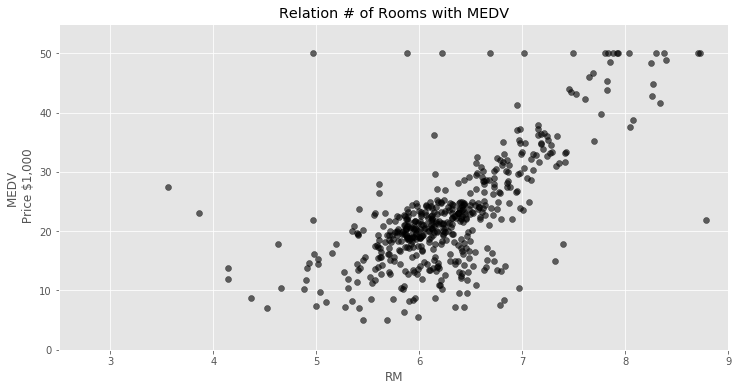

In [ ]:
# Example 5.23 (continued)  Scatter plot: number of rooms (RM) vs. home price (MEDV)
# A positive correlation is visible — more rooms → higher price, but not perfectly linear.

import matplotlib.pylab as plt
import matplotlib
%matplotlib inline
matplotlib.style.use('ggplot')

fig, ax1 = plt.subplots(1, 1, figsize=(10, 5))
ax1.scatter(X['RM'], y, color='black', alpha=0.6)
ax1.set_title('Boston Housing: Number of Rooms (RM) vs. Home Price (MEDV)')
ax1.set_xlim(2.5, 9)
ax1.set_xlabel('RM — Average number of rooms')
ax1.set_ylim(0, 55)
ax1.set_ylabel('MEDV — Median home value ($1,000s)')
plt.tight_layout()

In [ ]:
# Example 5.38  Fit a simple linear regression using only the RM feature
# MEDV = a × RM + b

from sklearn import linear_model
import pandas as pd

linear_regression = linear_model.LinearRegression()
linear_regression.fit(X=pd.DataFrame(X_train['RM']), y=y_train)
prediction = linear_regression.predict(X=pd.DataFrame(X_test['RM']))

print(f"Intercept (b): {linear_regression.intercept_:.4f}")
print(f"Slope (a)    : {linear_regression.coef_[0]:.4f}")
print(f"Equation     : MEDV = {linear_regression.coef_[0]:.2f} × RM + {linear_regression.intercept_:.2f}")

a value:  -32.39552264560753
b value:  [8.76050748]
MEDV = 8.76 * RM -32.40


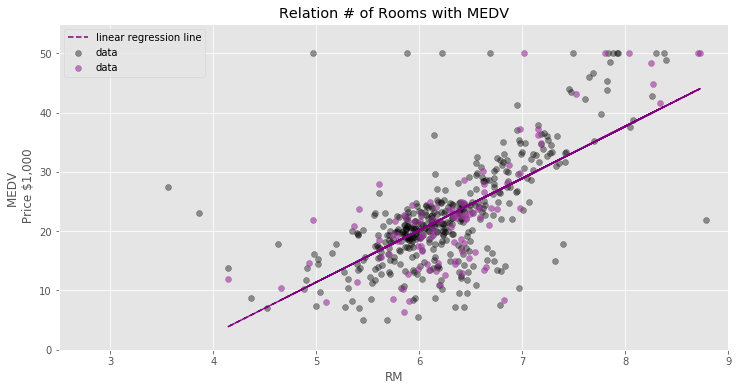

In [ ]:
# Example 5.39  Overlay the linear regression line on the scatter plot

fig, ax1 = plt.subplots(1, 1, figsize=(10, 5))
ax1.scatter(X_train['RM'], y_train, color='black', alpha=0.4, label='Train data')
ax1.scatter(X_test['RM'],  y_test,  color='#993299', alpha=0.6, label='Test data')
ax1.plot(X_test['RM'], prediction, color='purple', linestyle='--', label='Linear regression (RM only)')
ax1.set_xlim(2.5, 9)
ax1.set_xlabel('RM — Average number of rooms')
ax1.set_ylim(0, 55)
ax1.set_ylabel('MEDV — Median home value ($1,000s)')
ax1.set_title('Linear Regression: RM → MEDV')
ax1.legend()
plt.tight_layout()

In [ ]:
# Example 5.40  Compute RMSE for the linear regression baseline (RM feature only)

from sklearn.metrics import mean_squared_error
rmse_linear = np.sqrt(mean_squared_error(y_test, prediction))
print(f"Linear regression RMSE (RM only): {rmse_linear:.4f}")

RMSE: 6.383135


## Section 6 — XGBoost Regression Baseline

**Concept:** Before applying SHAP, we train an XGBoost regressor as our black-box model. A simple linear regression using only the `RM` (rooms) feature serves as a **baseline surrogate** — easy to interpret, but less accurate than the full XGBoost model.

| Model | Features | Expected RMSE |
|-------|---------|---------------|
| Linear regression (RM only) | 1 feature | ~6.5 |
| XGBoost (all 13 features) | 13 features | ~3.2 |

**What to observe:** How much does adding more features (via XGBoost) reduce the RMSE?  
**Try it yourself:** Try `n_estimators=200` in XGBRegressor — does the RMSE improve?

In [ ]:
# Example 5.41  Train an XGBoost regressor on the Boston Housing features
# Note: 'reg:linear' was deprecated; use 'reg:squarederror' instead.

import xgboost

# TODO: Train an XGBRegressor with objective='reg:squarederror' and random_state=1
# Then predict on X_test and store results in 'preds'
model = xgboost.XGBRegressor(objective="reg:squarederror", random_state=1)
model.fit(X_train, y_train)
preds = model.predict(X_test)

[09:44:02] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.


In [ ]:
# Example 5.42  Compute RMSE for the XGBoost model (all 13 features)

from sklearn.metrics import mean_squared_error
rmse_xgb = np.sqrt(mean_squared_error(y_test, preds))
print(f"XGBoost RMSE (all features): {rmse_xgb:.4f}")
print(f"Improvement over linear regression: {rmse_linear - rmse_xgb:.4f} lower RMSE")

RMSE: 2.818447


In [ ]:
# Example 5.43  Define the SHAP explainer and compute Shapley values
# Compatibility note: newer shap/xgboost versions require get_booster() or a predict callable.

shap.initjs()

try:
    # Preferred: pass the underlying booster directly
    explainer = shap.TreeExplainer(model.get_booster())
    shap_values = explainer.shap_values(X_train)
    base_value = float(np.asarray(explainer.expected_value).reshape(-1)[0])
except Exception:
    # Fallback: use model.predict as a callable (PermutationExplainer)
    explainer = shap.Explainer(model.predict, X_train)
    shap_explanation = explainer(X_train)
    shap_values = shap_explanation.values
    base_value = float(np.asarray(shap_explanation.base_values).reshape(-1)[0])

print(f"Base value (expected prediction): {base_value:.3f}")

# Visualize the first prediction's explanation
# matplotlib=True produces a static PNG that works without a JS environment
shap.force_plot(base_value, shap_values[0, :], X_train.iloc[0, :], matplotlib=True)

Setting feature_perturbation = "tree_path_dependent" because no background data was given.


Text(0, 0.5, 'MEDV \n Price $1,000')

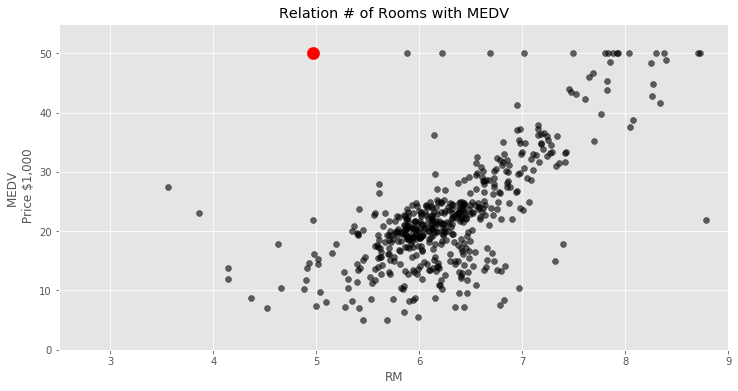

In [ ]:
# Example 5.44  Highlight data point 259 on the scatter plot
# Red dot = the specific data point we will explain with SHAP

fig, ax1 = plt.subplots(1, 1, figsize=(10, 5))
idx = 259

ax1.scatter(X['RM'], y, color='black', alpha=0.6, label='All data')
ax1.scatter(X_train['RM'].iloc[idx], y_train.iloc[idx],
            c='red', s=150, zorder=5, label=f'Data point {idx}')
ax1.set_title(f'Boston Housing: data point {idx} highlighted (red)')
ax1.set_xlim(2.5, 9)
ax1.set_xlabel('RM')
ax1.set_ylim(0, 55)
ax1.set_ylabel('MEDV ($1,000s)')
ax1.legend()
plt.tight_layout()
print(f"Data point {idx}: RM = {X_train['RM'].iloc[idx]:.2f}, "
      f"actual price = ${y_train.iloc[idx]:.1f}k")

## Section 7 — SHAP Force Plots: Explaining Single Predictions

**Concept:** A **force plot** shows a single prediction as a tug-of-war between features:

```
base value ──[LSTAT pushes ←]──[RM pushes →]──[RAD pushes ←]──► actual prediction
```

- **Base value** (`base_value`): the average model prediction across all training samples
- **Red bars**: features that increase the prediction (push price up)
- **Blue bars**: features that decrease the prediction (push price down)

The SHAP values sum exactly to: `prediction = base_value + Σ(shap_values)`

**What to observe:** For data point 259, check which feature has the largest absolute SHAP value. Does this match your intuition about the feature's influence on price?

**Try it yourself:** Find a training sample with a very high predicted price (`preds` array) and another with a very low price — compare their force plots. Do different features dominate?

In [ ]:
# Example 5.45  Force plot for data point 259
# base_value was computed in the cell above (equals explainer.expected_value)

shap.initjs()

# TODO: Call shap.force_plot for training sample index 259
# Hint: shap.force_plot(base_value, shap_values[259, :], X_train.iloc[259, :], matplotlib=True)
shap.force_plot(base_value, shap_values[259, :], X_train.iloc[259, :], matplotlib=True)

In [ ]:
# Example 5.46  Force plot for the full training set (stacked view)
# This view lets you see how features drive predictions across all training samples.

shap.initjs()
shap.force_plot(base_value, shap_values, X_train)

**Q3:** Look at the stacked force plot (all training data).  
- Which features appear most consistently red (raising predictions)?
- Do the clusters in the stacked plot suggest any interesting patterns?

**Answer:** *(Write your answer here)*

## Section 8 — SHAP Global Analysis: Dependence & Summary Plots

**Concept:** While force plots explain *one prediction*, global SHAP visualizations reveal *overall* feature behavior:

| Plot | What it shows |
|------|--------------|
| **Dependence plot** | SHAP value vs. feature value for one feature (colored by interaction partner) |
| **Summary (beeswarm)** | All features ranked by mean \|SHAP\|; each dot is one data point |
| **Summary (bar)** | Same ranking as bar chart — global feature importance via SHAP |

**Reading the beeswarm plot:**
- **Y-axis position** = feature (ranked by importance, top = most important)
- **X-axis** = SHAP value (positive = increases prediction)
- **Dot color** = feature value (red = high, blue = low)
- Pattern: *"red dots on right"* means high feature value → higher prediction

**What to observe:** Compare the SHAP-based global importance with XGBoost's built-in `plot_importance`. Do they rank features the same way? Where do they disagree?

**Try it yourself:** Call `shap.dependence_plot("LSTAT", shap_values, X_train)` — which feature does SHAP choose as the interaction coloring variable, and why?

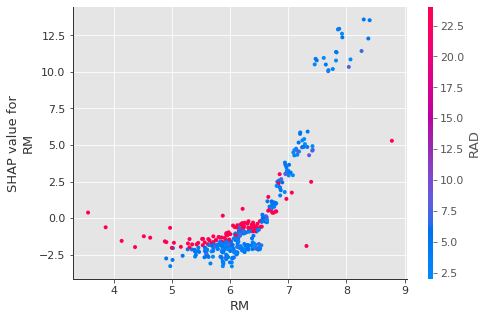

In [ ]:
# Example 5.47  SHAP Dependence Plot: RM feature
# X-axis: RM value | Y-axis: SHAP value | Color: automatically chosen interaction feature
# Upward trend = higher RM → higher price contribution

shap.dependence_plot("RM", shap_values, X_train)

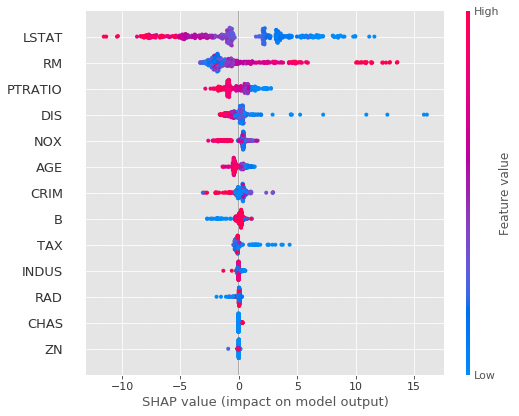

In [ ]:
# Example 5.48  SHAP Beeswarm Summary Plot
# Each dot = one data point; color = feature value (red=high, blue=low)
# Features sorted top-to-bottom by mean |SHAP| (most important at top)

shap.summary_plot(shap_values, X_train)

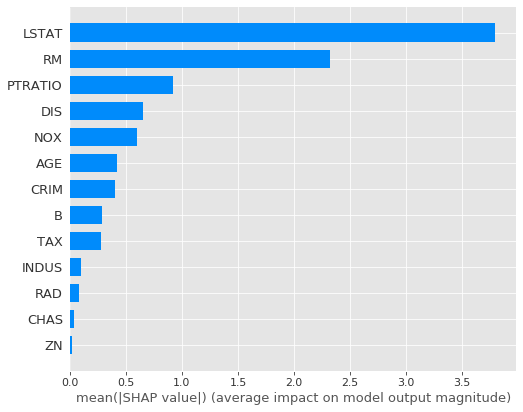

In [ ]:
# Example 5.49  SHAP Bar Summary Plot — mean |SHAP| per feature (global importance ranking)

shap.summary_plot(shap_values, X_train, plot_type="bar")

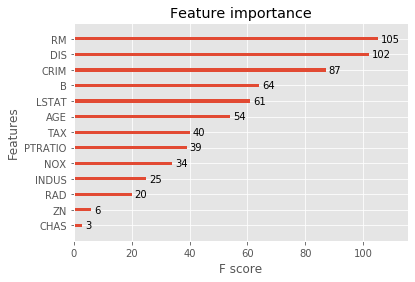

In [ ]:
# Example 5.50  XGBoost built-in feature importance
# Compare this ranking to the SHAP bar plot above — do they agree?

import xgboost
xgboost.plot_importance(model)
plt.title("XGBoost Built-in Feature Importance (F-score)")
plt.tight_layout()

## Lab Complete — Review Questions

**Q4:** Compare LIME and SHAP in your own words.
- Which method gave you more intuitive explanations?
- Which method do you trust more, and why?

**Answer:** *(Write your answer here)*

---

**Q5:** LIME explanations can change if you run them again (stochastic). SHAP (TreeSHAP) gives deterministic results. How does this difference affect your confidence in each method's explanations?

**Answer:** *(Write your answer here)*

---

### Key Takeaways

| | LIME | SHAP |
|---|---|---|
| **Approach** | Local perturbation + linear surrogate | Shapley values (game theory) |
| **Model-agnostic?** | Yes | Yes (TreeSHAP is tree-specific) |
| **Consistency** | Stochastic — results may vary | Deterministic (TreeSHAP) |
| **Global explanations** | Limited | Yes (summary, dependence plots) |
| **Speed** | Slow (sampling) | Fast for tree models |

> Both methods are complementary. In practice, use SHAP for global insights and LIME when you need fast, model-agnostic local explanations.